# 03 · Series de tiempo, Fourier y wavelets (T-06, bloques D, O y P)

**Dónde:** `pipeline/src/signals/temporal.py`. **Por qué:** entender la dinámica del consumo y detectar fugas en la
telemetría horaria. **Cómo:** descomposición y predicción de la serie mensual, media móvil, autocorrelación y cambio
de régimen; FFT con conversión frecuencia → periodo y reconstrucción filtrada; DWT/SWT db4 con energía por nivel y
detección de fugas contra la regla de flujo nocturno. **Con qué datos:** consumo mensual de recibos y telemetría
horaria de 40 tomas; `tiene_fuga` solo para evaluar.

In [1]:
import sys, pathlib
raiz = pathlib.Path.cwd()
while not (raiz / "pipeline").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 120)
from pipeline.notebooks.graficas import dibujar, tabla

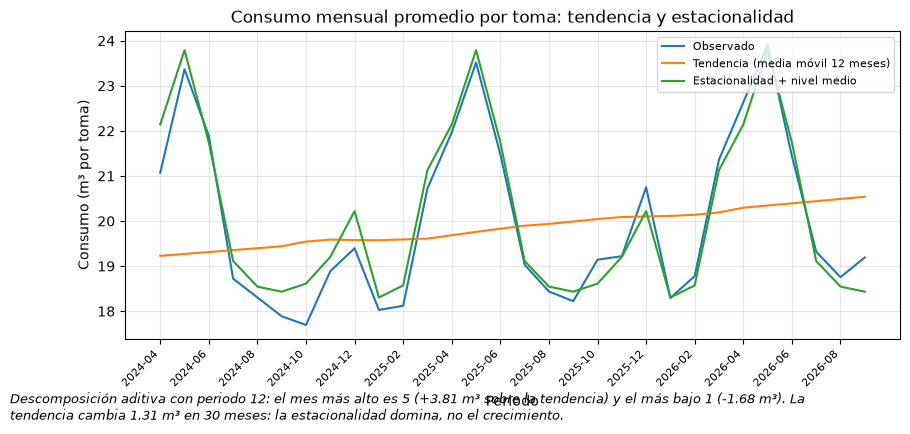

**Pronóstico de consumo mensual: prueba en los últimos 6 meses**

,modelo,MAE,RMSE,MAPE_%
0,"Ingenuo estacional (mismo mes, año previo)",0.445,0.535,2.16
1,Holt-Winters aditivo (tendencia + estacionalidad 12),0.454,0.517,2.18
2,Ingenuo (último mes),1.785,1.990,8.73


_Con entrenamiento hasta 2026-03 y prueba 2026-04–2026-09, el mejor es «Ingenuo estacional (mismo mes, año previo)» (MAE 0.445 m³ contra 1.785 del ingenuo): modelar la estacionalidad es lo que reduce el error._  
`fuente: pipeline/src/signals/temporal.py`

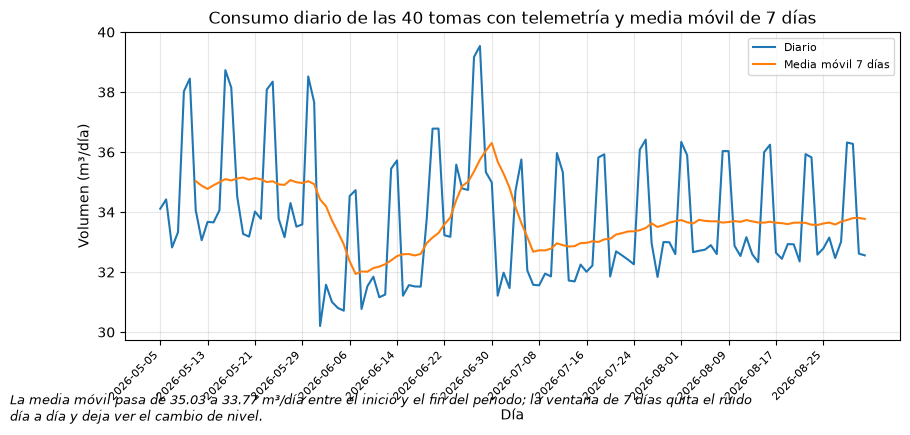

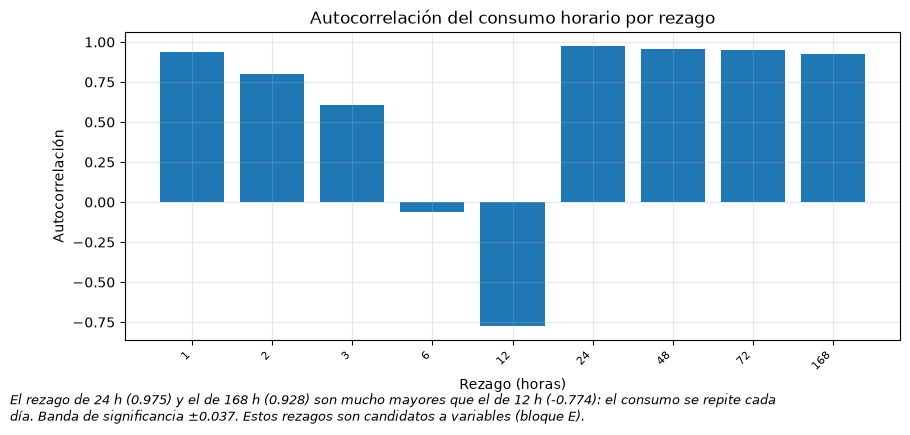

**Cambio de régimen en el consumo diario (un punto de cambio en la media)**

,indicador,valor
0,Fecha del cambio,2026-06-01
1,Media antes (m³/día),35.047
2,Media después (m³/día),33.442
3,Cambio relativo (%),-4.58
4,t de Welch,3.456
5,valor p,0.00132


_H0: la media diaria es igual antes y después de 2026-06-01. p = 0.00132 < 0.05: se rechaza H0; el consumo baja 4.58 %. El total mezcla estacionalidad y fugas: un cambio en el agregado no dice qué tomas lo causan; eso lo resuelve el análisis por toma con Wavelets._  
`fuente: pipeline/src/signals/temporal.py`

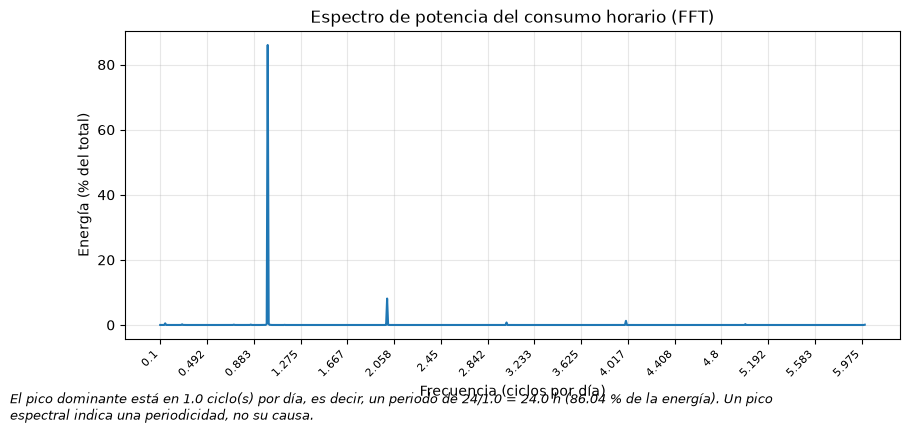

**Frecuencias dominantes y su periodo**

,frecuencia_ciclos_por_hora,ciclos_por_dia,periodo_horas,energia_%
0,0.04167,1.000,24.00,86.04
1,0.08333,2.000,12.00,8.13
2,0.16667,4.000,6.00,1.28
3,0.12500,3.000,8.00,0.77
4,0.00590,0.142,169.41,0.50


_Periodo = 1/frecuencia. El ciclo diario y sus armónicos (24, 12, 8, 6 h…) concentran 96.56 % de la energía: el patrón es un día con dos picos de uso (mañana y tarde), lo que sugiere planear presión y bombeo por franja horaria._  
`fuente: pipeline/src/signals/temporal.py`

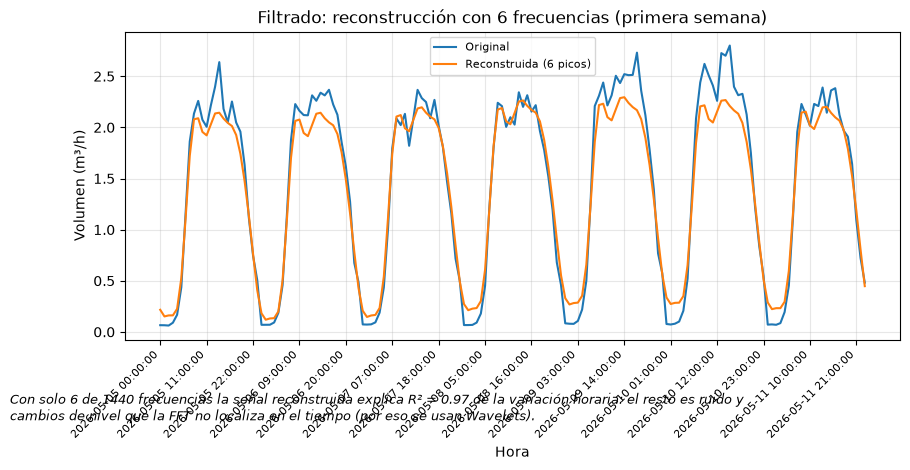

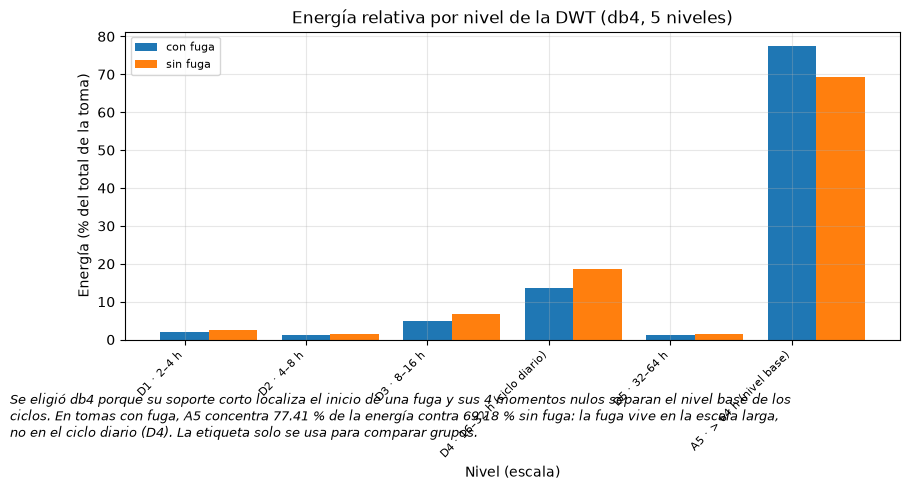

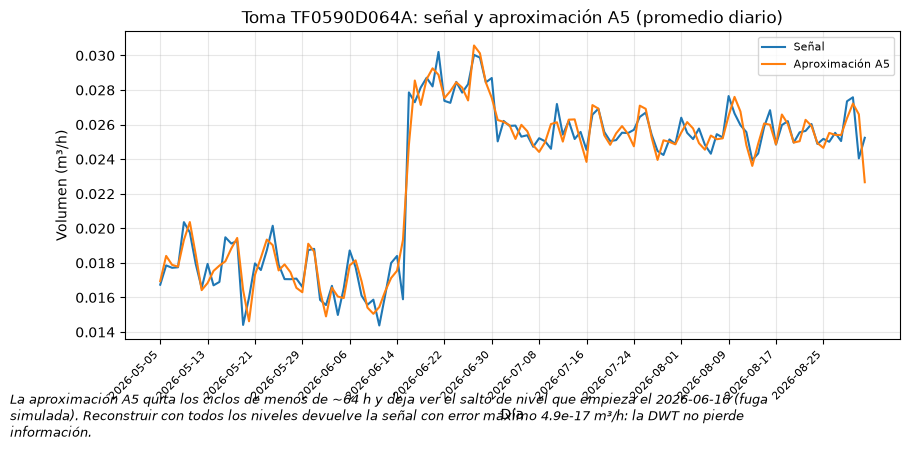

**Detección de fugas: Wavelets contra flujo mínimo nocturno**

,metodo,umbral,VP,FP,FN,precision,recall,F1,retraso_mediano_h,precision_por_hora,recall_por_hora
0,Wavelet SWT db4 (A5/detalles),1.667,14,7,0,0.667,1.0,0.800,121.0,0.995,0.819
1,Flujo mínimo nocturno 2–4 h (clásico),1.481,14,1,0,0.933,1.0,0.966,47.0,1.000,0.964


_Umbral fijado sin etiquetas (percentil 99.5 del periodo de referencia) y alarma con 24 h seguidas. Wavelets: 14 de 14 fugas, 7 falsas alarmas, retraso mediano 121.0 h. Nocturno: 14 de 14, 1 falsas, 47.0 h. Gana el flujo nocturno en F1: para una fuga constante, la hora de menor uso es la señal más limpia; Wavelets aporta la descomposición por escala y variables para modelos. tiene_fuga solo mide el acierto; nunca entra al detector._  
`fuente: pipeline/src/signals/temporal.py`

**Sensibilidad del detector Wavelet al umbral**

,factor_umbral,umbral,VP,FP,FN,F1,retraso_mediano_h
0,0.8,1.334,14,26,0,0.519,101.5
1,1.0,1.667,14,7,0,0.800,121.0
2,1.2,2.001,14,0,0,1.000,134.5
3,1.5,2.501,11,0,3,0.880,163.0


_Un umbral más bajo detecta antes pero arriesga falsas alarmas; uno más alto las evita pero tarda más. La tabla muestra qué tan estable es el resultado sin elegir el umbral con las etiquetas._  
`fuente: pipeline/src/signals/temporal.py`

**Anomalías detectadas contra quejas de fuga**

,indicador,valor
0,Tomas con alarma,21
1,…con queja de fuga desde 7 días antes de la alarma,0


_0 de 21 tomas con alarma tienen una queja de fuga cercana: en esta simulación las quejas no bastan para encontrar fugas, y la telemetría sí las señala. Cada alarma requiere inspección antes de actuar._  
`fuente: pipeline/src/signals/temporal.py`

In [2]:
from pipeline.src.signals.temporal import ejecutar
r = ejecutar()
for modulo in ("series", "fourier", "wavelets"):
    for x in r[modulo]:
        dibujar(x["payload"])

## Conclusiones

In [3]:
for modulo in ("series", "fourier", "wavelets"):
    for x in r[modulo]:
        print(f"- {x['payload']['titulo']}: {x['payload']['conclusion']}")

- Consumo mensual promedio por toma: tendencia y estacionalidad: Descomposición aditiva con periodo 12: el mes más alto es 5 (+3.81 m³ sobre la tendencia) y el más bajo 1 (-1.68 m³). La tendencia cambia 1.31 m³ en 30 meses: la estacionalidad domina, no el crecimiento.
- Pronóstico de consumo mensual: prueba en los últimos 6 meses: Con entrenamiento hasta 2026-03 y prueba 2026-04–2026-09, el mejor es «Ingenuo estacional (mismo mes, año previo)» (MAE 0.445 m³ contra 1.785 del ingenuo): modelar la estacionalidad es lo que reduce el error.
- Consumo diario de las 40 tomas con telemetría y media móvil de 7 días: La media móvil pasa de 35.03 a 33.77 m³/día entre el inicio y el fin del periodo; la ventana de 7 días quita el ruido día a día y deja ver el cambio de nivel.
- Autocorrelación del consumo horario por rezago: El rezago de 24 h (0.975) y el de 168 h (0.928) son mucho mayores que el de 12 h (-0.774): el consumo se repite cada día. Banda de significancia ±0.037. Estos rezagos son candi